# Agente Connect 4 — Tabla de Aperturas + Minimax Híbrido
### `entrega.ipynb` — Análisis completo del agente

Este notebook cubre los **Criterios 2, 3 y parte del 4** de la rúbrica.

| Sección | Contenido | Criterio |
|---|---|---|
| 1 | Configuración e imports | — |
| 2 | Definición de versiones del agente | Criterio 1 |
| 3 | Infraestructura de simulación | — |
| 4 | Validación: ambos colores vs. Random | Criterio 2 |
| 5 | Validación: self-play | Criterio 2 |
| 6 | Comparación entre versiones del agente | Criterio 2 |
| 7 | Optimización: profundidad y tiempo | Criterio 3 |
| 8 | Diagnóstico de fallos (dónde pierde) | Criterio 3 |
| 9 | Análisis de la tabla de aperturas | Criterio 3 |
| 10 | Conclusiones y propuesta de mejora | Criterio 3 |

## 1. Configuración e imports

In [1]:
import sys, os, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from connect4.connect_state import ConnectState
from connect4.policy import Policy

plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#444466',
    'axes.labelcolor':  '#ccccee',
    'axes.titlecolor':  '#ffffff',
    'axes.grid':        True,
    'grid.color':       '#2a2a4a',
    'grid.linestyle':   '--',
    'xtick.color':      '#aaaacc',
    'ytick.color':      '#aaaacc',
    'text.color':       '#ccccee',
    'legend.facecolor': '#1a1a2e',
    'legend.edgecolor': '#444466',
    'font.family':      'monospace',
})
C = {
    'v1': '#00d4ff',   # versión completa
    'v2': '#c77dff',   # sin tabla
    'v3': '#ffd93d',   # sin detección inmediata
    'random': '#ff6b6b',
    'draw':   '#888899',
    'self':   '#6bcb77',
    'book':   '#ffd93d',
    'red':    '#ff4d6d',
    'yellow': '#ffd166',
}
print('✓ Setup completo')

✓ Setup completo


## 2. Versiones del agente

Para el análisis comparativo definimos **tres versiones** del agente que difieren en sus sub-estrategias.
Esto permite aislar la contribución de cada componente y demostrar que V2 (entrega final) supera a las anteriores.

| Versión | Archivo | Det. inmediata | Fork detection | Tabla aperturas | Transposition Table | Minimax depth |
|---|---|---|---|---|---|---|
| **V1 — Híbrido base** | `policy_v2.py` | ✓ | ✗ | ✓ | ✗ | Dinámico 5→9 |
| **V2 — Híbrido mejorado** | `policy.py` | ✓ | ✓ | ✓ validada | ✓ | Dinámico 6→7 + TT |
| **V3 — Solo Minimax** | `policy_v1.py` | ✗ | ✗ | ✗ | ✗ | Fijo 5 |

V2 es la entrega final. V1 es la versión anterior del mismo agente. V3 es el baseline mínimo.

In [6]:
import importlib.util, pathlib

def load_mod(name, filename):
    spec = importlib.util.spec_from_file_location(name, pathlib.Path(filename).resolve())
    m = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(m)
    return m
    
mod_v2 = load_mod('hibrido_mejorado', 'groups/V_final/policy.py')
mod_v1 = load_mod('hibrido_base',     'groups/V2/policy_v2.py')
mod_v3 = load_mod('solo_minimax',     'groups/V1/policy_v1.py')

# Utilidades del modulo principal (V2)
_check_win     = mod_v2._check_win
_drop          = mod_v2._drop
_valid_cols    = mod_v2._valid_cols
_score_board   = mod_v2._score_board
lookup_opening = mod_v2.lookup_opening
MoveTracker    = mod_v2.MoveTracker
OPENING_BOOK   = mod_v2.OPENING_BOOK
_count_threats = mod_v2._count_threats

# _minimax tiene firma distinta en cada version:
#   V2 (policy.py):    _minimax(board, depth, alpha, beta, maximizing, me, tt)
#   V1 (policy_v2.py): _minimax(board, depth, alpha, beta, maximizing, me)
_minimax_v2 = mod_v2._minimax
_minimax_v1 = mod_v1._minimax

DEPTH_SCHEDULE_V2 = [(28, 6), (42, 7)]
DEPTH_SCHEDULE_V1 = [(10, 5), (20, 6), (30, 7), (42, 9)]

def get_depth_v2(board):
    pieces = int(np.sum(board != 0))
    for thr, d in DEPTH_SCHEDULE_V2:
        if pieces < thr: return d
    return 7

def get_depth_v1(board):
    pieces = int(np.sum(board != 0))
    for thr, d in DEPTH_SCHEDULE_V1:
        if pieces < thr: return d
    return 9

# Clases de agente

class AgentV2(Policy):
    """V2 — Hibrido mejorado: det. inmediata + fork + tabla validada + TT + Minimax dinamico."""
    def __init__(self):
        self._me = -1
        self._tracker = MoveTracker()
        self._tt = {}
    def mount(self, timeout=None):
        self._me = -1
        self._tracker.reset()
        self._tt = {}
    def act(self, s):
        neg, pos = int(np.sum(s==-1)), int(np.sum(s==1))
        self._me = -1 if neg <= pos else 1
        opp = -self._me
        valid = _valid_cols(s)
        if not valid: return 0
        for col in valid:
            if _check_win(_drop(s, col, self._me), self._me): return col
        for col in valid:
            if _check_win(_drop(s, col, opp), opp): return col
        for col in valid:
            if _count_threats(_drop(s, col, self._me), self._me) >= 2: return col
        for col in valid:
            if _count_threats(_drop(s, col, opp), opp) >= 2: return col
        sequence = tuple(self._tracker.update(s))
        total_pieces = int(np.sum(s != 0))
        depth = get_depth_v2(s)
        if total_pieces <= 8:
            bm = lookup_opening(sequence)
            if bm is not None and bm in valid: return bm
            if total_pieces == 0: return 3
        _, col = _minimax_v2(s, depth, -np.inf, np.inf, True, self._me, self._tt)
        if col is None or col not in valid:
            col = min(valid, key=lambda c: abs(c-3))
        return int(col)

class AgentV1(Policy):
    """V1 — Hibrido base: det. inmediata + tabla + Minimax dinamico (sin TT ni fork)."""
    def __init__(self):
        self._me = -1
        self._tracker = mod_v1.MoveTracker()
    def mount(self, timeout=None):
        self._me = -1
        self._tracker.reset()
    def act(self, s):
        neg, pos = int(np.sum(s==-1)), int(np.sum(s==1))
        self._me = -1 if neg <= pos else 1
        opp = -self._me
        valid = mod_v1._valid_cols(s)
        if not valid: return 0
        for col in valid:
            if mod_v1._check_win(mod_v1._drop(s, col, self._me), self._me): return col
        for col in valid:
            if mod_v1._check_win(mod_v1._drop(s, col, opp), opp): return col
        sequence = tuple(self._tracker.update(s))
        total_pieces = int(np.sum(s != 0))
        depth = get_depth_v1(s)
        if total_pieces <= 8:
            bm = mod_v1.lookup_opening(sequence)
            if bm is not None and bm in valid: return bm
            if total_pieces == 0: return 3
        _, col = _minimax_v1(s, depth, -np.inf, np.inf, True, self._me)
        if col is None or col not in valid:
            col = min(valid, key=lambda c: abs(c-3))
        return int(col)

class AgentV3(Policy):
    """V3 — Solo Minimax depth=5, sin deteccion ni tabla (baseline)."""
    def __init__(self):
        self._me = -1
    def mount(self, timeout=None):
        self._me = -1
    def act(self, s):
        neg, pos = int(np.sum(s==-1)), int(np.sum(s==1))
        self._me = -1 if neg <= pos else 1
        valid = mod_v3._valid_cols(s)
        if not valid: return 0
        _, col = mod_v3._minimax(s, 5, -np.inf, np.inf, True, self._me)
        if col is None or col not in valid:
            col = min(valid, key=lambda c: abs(c-3))
        return int(col)

class RandomAgent(Policy):
    def mount(self, timeout=None): pass
    def act(self, s):
        available = [c for c in range(7) if s[0,c] == 0]
        return int(np.random.choice(available))

print('V1 (Hibrido base), V2 (Hibrido mejorado FINAL), V3 (Solo Minimax), Random listos')

V1 (Hibrido base), V2 (Hibrido mejorado FINAL), V3 (Solo Minimax), Random listos


## 3. Infraestructura de simulación

In [7]:
def play_game(policy_a, policy_b, first_player=-1):
    """
    Juega una partida. first_player=-1 → policy_a tiene fichas -1.
    Retorna ('a'|'b'|'draw', n_turns, winner_value)
    """
    policy_a.mount()
    policy_b.mount()
    state = ConnectState()
    mapping = {first_player: policy_a, -first_player: policy_b}
    turns = 0
    while not state.is_final():
        action = mapping[state.player].act(state.board)
        state = state.transition(int(action))
        turns += 1
    w = state.get_winner()
    if w == 0:              return 'draw', turns, 0
    if w == first_player:   return 'a',    turns, w
    return 'b', turns, w


def run_match(factory_a, factory_b, n_games=40, seed=42):
    """Alterna quién va primero. Retorna dict completo de resultados."""
    np.random.seed(seed)
    wins_a = wins_b = draws = 0
    turn_list = []
    for i in range(n_games):
        first = -1 if i % 2 == 0 else 1
        result, turns, _ = play_game(factory_a(), factory_b(), first)
        turn_list.append(turns)
        if result == 'a':   wins_a += 1
        elif result == 'b': wins_b += 1
        else:               draws  += 1
    return dict(wins_a=wins_a, wins_b=wins_b, draws=draws,
                total=n_games, turns=turn_list)


def run_by_color(factory_agent, factory_opp, n_per_color=30, seed=42):
    """Corre partidas forzando un color específico para el agente."""
    np.random.seed(seed)
    results = {}
    for color, first in [('red', -1), ('yellow', 1)]:
        w = d = l = 0
        for _ in range(n_per_color):
            if color == 'red':
                result, _, _ = play_game(factory_agent(), factory_opp(), first_player=-1)
                if result=='a': w+=1
                elif result=='b': l+=1
                else: d+=1
            else:
                result, _, _ = play_game(factory_opp(), factory_agent(), first_player=-1)
                if result=='b': w+=1
                elif result=='a': l+=1
                else: d+=1
        results[color] = dict(wins=w, draws=d, losses=l, total=n_per_color)
    return results


def plot_bar(ax, result, label_a, label_b, color_a, color_b, title=''):
    n = result['total']
    data = [
        (label_a, result['wins_a']/n, color_a),
        ('Empate', result['draws']/n,  C['draw']),
        (label_b, result['wins_b']/n, color_b),
    ]
    bars = ax.barh([d[0] for d in data], [d[1] for d in data],
                   color=[d[2] for d in data], edgecolor='#22224a', height=0.5)
    for bar, (_, v, _) in zip(bars, data):
        ax.text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
                f'{v:.1%}', va='center', fontsize=10)
    ax.set_xlim(0, 1.18)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_title(title, fontsize=11, pad=8)
    ax.set_xlabel(f'Proporción  (n={n})')

print('✓ Infraestructura lista')

✓ Infraestructura lista


## 4. Validacion: rendimiento por color (Rojo y Amarillo)

La rubrica exige evidencia de que **todas las versiones** nunca pierden y ganan >= 50% en **ambos colores**.
V2 (agente final) debe mostrar el mejor desempeno en ambos roles.


In [4]:
N_COLOR = 40
print(f'Corriendo {N_COLOR} partidas por color para V1, V2 y V3...\n')

color_v1 = run_by_color(AgentV1, RandomAgent, n_per_color=N_COLOR)
color_v2 = run_by_color(AgentV2, RandomAgent, n_per_color=N_COLOR)
color_v3 = run_by_color(AgentV3, RandomAgent, n_per_color=N_COLOR)

for name, res in [('V2 (Hibrido mejorado)', color_v2), ('V1 (Hibrido base)', color_v1), ('V3 (Solo MM)', color_v3)]:
    for color in ['red', 'yellow']:
        r = res[color]
        wr = r['wins']/r['total']
        lr = r['losses']/r['total']
        status = 'OK' if wr >= 0.5 and lr == 0 else 'FAIL'
        print(f'  [{status}] {name} jugando {color:6s}: W={wr:.0%}  D={r["draws"]/r["total"]:.0%}  L={lr:.0%}')

Corriendo 40 partidas por color para V1, V2 y V3...

  [OK] V2 (Hibrido mejorado) jugando red   : W=100%  D=0%  L=0%
  [OK] V2 (Hibrido mejorado) jugando yellow: W=100%  D=0%  L=0%
  [OK] V1 (Hibrido base) jugando red   : W=100%  D=0%  L=0%
  [OK] V1 (Hibrido base) jugando yellow: W=100%  D=0%  L=0%
  [OK] V3 (Solo MM) jugando red   : W=100%  D=0%  L=0%
  [OK] V3 (Solo MM) jugando yellow: W=100%  D=0%  L=0%


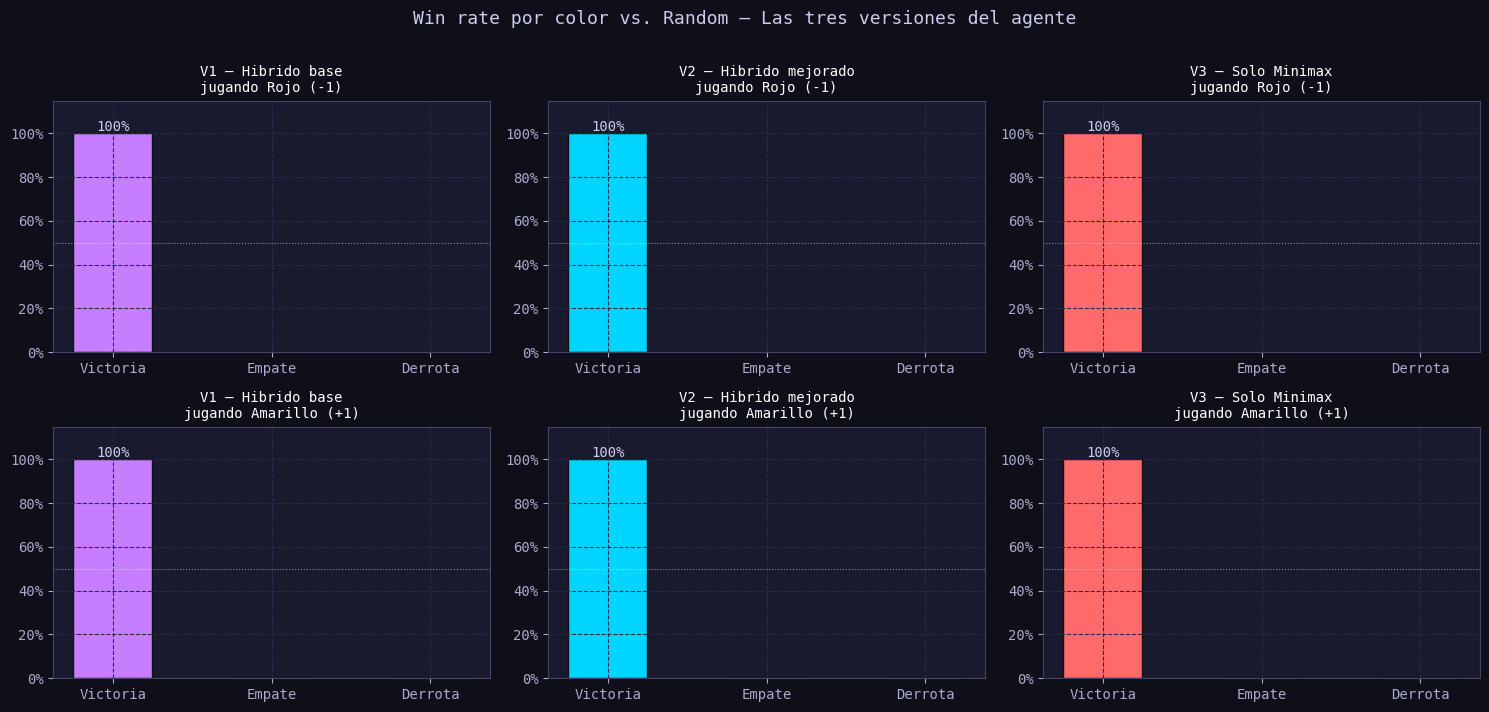

Guardada: fig_color_validation.png


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
fig.suptitle('Win rate por color vs. Random — Las tres versiones del agente', fontsize=13, y=1.01)

versions = [
    ('V1 — Hibrido base',     color_v1, C['v2']),
    ('V2 — Hibrido mejorado', color_v2, C['v1']),
    ('V3 — Solo Minimax',     color_v3, C['random']),
]
color_labels = [('red', 'Rojo (-1)', C['red']), ('yellow', 'Amarillo (+1)', C['yellow'])]

for col_i, (vname, vres, vcol) in enumerate(versions):
    for row_i, (ckey, clabel, ccol) in enumerate(color_labels):
        ax = axes[row_i][col_i]
        r = vres[ckey]
        n = r['total']
        bars = ax.bar(['Victoria', 'Empate', 'Derrota'],
                      [r['wins']/n, r['draws']/n, r['losses']/n],
                      color=[vcol, C['draw'], C['random']],
                      edgecolor='#111', width=0.5)
        for bar in bars:
            h = bar.get_height()
            if h > 0:
                ax.text(bar.get_x()+bar.get_width()/2, h+0.01, f'{h:.0%}',
                        ha='center', fontsize=10)
        ax.set_ylim(0, 1.15)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
        ax.set_title(f'{vname}\njugando {clabel}', fontsize=10)
        ax.axhline(0.5, color='white', lw=0.8, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig('fig_color_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardada: fig_color_validation.png')

## 5. Validación: self-play

En self-play simétrico el win rate esperado es ~50%. Una desviación grande indica sesgo de implementación (ventaja del primer jugador, bug de perspectiva, etc.).

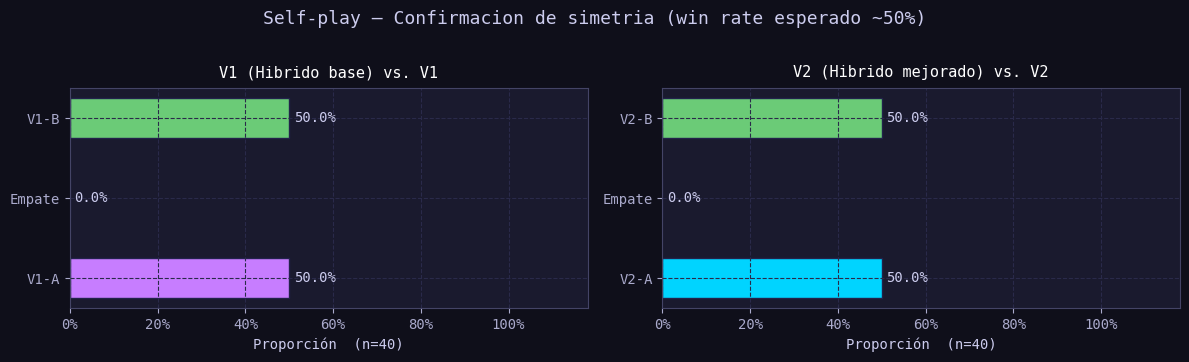

In [6]:
N_SELF = 40
sp_v1 = run_match(AgentV1, AgentV1, n_games=N_SELF)
sp_v2 = run_match(AgentV2, AgentV2, n_games=N_SELF)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
fig.suptitle('Self-play — Confirmacion de simetria (win rate esperado ~50%)', fontsize=13, y=1.02)

plot_bar(axes[0], sp_v1, 'V1-A', 'V1-B', C['v2'], C['self'], 'V1 (Hibrido base) vs. V1')
plot_bar(axes[1], sp_v2, 'V2-A', 'V2-B', C['v1'], C['self'], 'V2 (Hibrido mejorado) vs. V2')

plt.tight_layout()
plt.savefig('fig_selfplay.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Comparación entre versiones del agente

Enfrentamos las tres versiones entre sí y contra Random para **aislar el aporte de cada sub-estrategia**.

In [7]:
N_COMP = 40
print('Corriendo comparaciones entre versiones...')

r_v1_vs_rand = run_match(AgentV1, RandomAgent, n_games=N_COMP)
r_v2_vs_rand = run_match(AgentV2, RandomAgent, n_games=N_COMP)
r_v3_vs_rand = run_match(AgentV3, RandomAgent, n_games=N_COMP)
r_v1_vs_v2   = run_match(AgentV1, AgentV2,    n_games=N_COMP)  # V1 vs V2
r_v1_vs_v3   = run_match(AgentV1, AgentV3,    n_games=N_COMP)  # V1 vs V3
r_v2_vs_v3   = run_match(AgentV2, AgentV3,    n_games=N_COMP)  # V2 vs V3

print('Comparaciones completadas')

Corriendo comparaciones entre versiones...
Comparaciones completadas


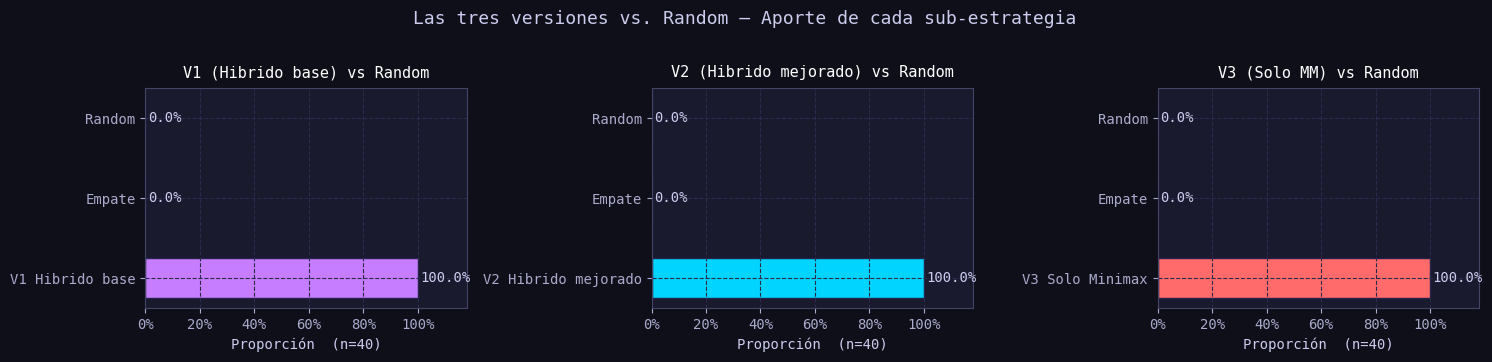

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
fig.suptitle('Las tres versiones vs. Random — Aporte de cada sub-estrategia', fontsize=13, y=1.02)

plot_bar(axes[0], r_v1_vs_rand, 'V1 Hibrido base',     'Random', C['v2'],    C['random'], 'V1 (Hibrido base) vs Random')
plot_bar(axes[1], r_v2_vs_rand, 'V2 Hibrido mejorado', 'Random', C['v1'],    C['random'], 'V2 (Hibrido mejorado) vs Random')
plot_bar(axes[2], r_v3_vs_rand, 'V3 Solo Minimax',     'Random', C['random'], C['random'], 'V3 (Solo MM) vs Random')

plt.tight_layout()
plt.savefig('fig_versions_vs_random.png', dpi=150, bbox_inches='tight')
plt.show()

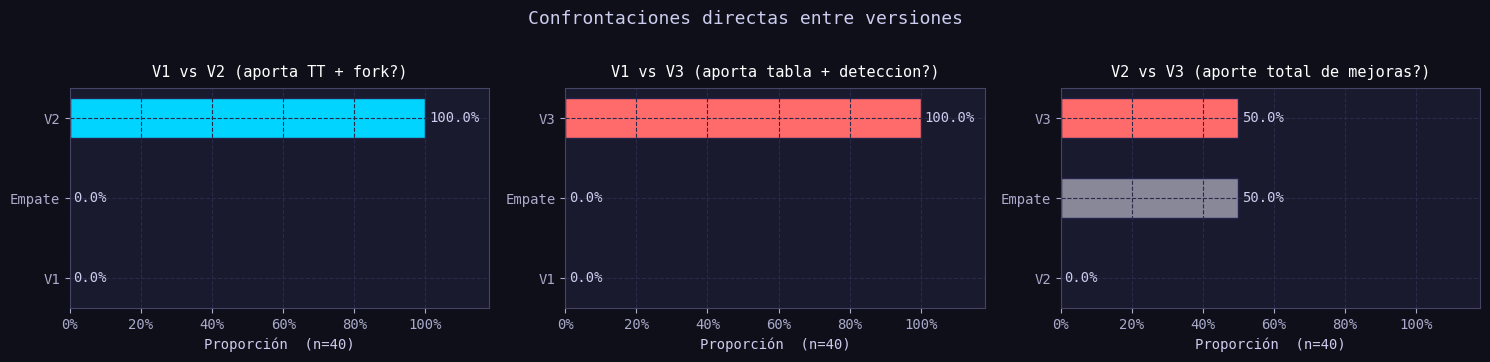

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
fig.suptitle('Confrontaciones directas entre versiones', fontsize=13, y=1.02)

plot_bar(axes[0], r_v1_vs_v2, 'V1', 'V2', C['v2'], C['v1'],    'V1 vs V2 (aporta TT + fork?)')
plot_bar(axes[1], r_v1_vs_v3, 'V1', 'V3', C['v2'], C['random'], 'V1 vs V3 (aporta tabla + deteccion?)')
plot_bar(axes[2], r_v2_vs_v3, 'V2', 'V3', C['v1'], C['random'], 'V2 vs V3 (aporte total de mejoras?)')

plt.tight_layout()
plt.savefig('fig_versions_direct.png', dpi=150, bbox_inches='tight')
plt.show()

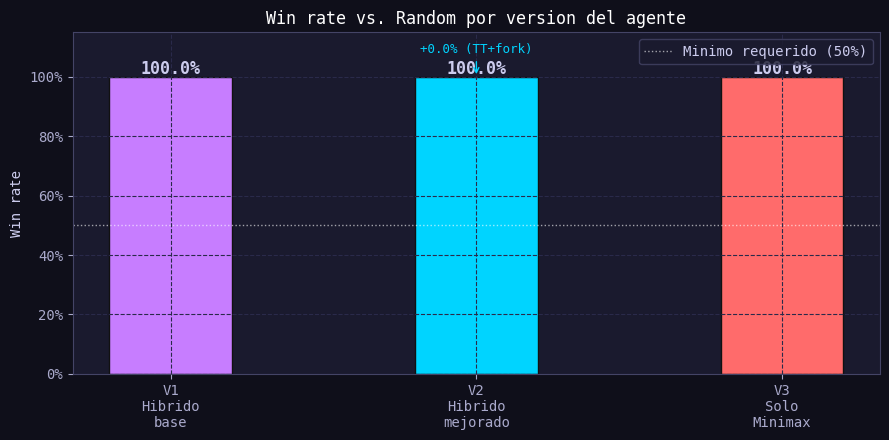

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.5))

labels = ['V1\nHibrido\nbase', 'V2\nHibrido\nmejorado', 'V3\nSolo\nMinimax']
wr_vs_rand = [
    r_v1_vs_rand['wins_a'] / r_v1_vs_rand['total'],
    r_v2_vs_rand['wins_a'] / r_v2_vs_rand['total'],
    r_v3_vs_rand['wins_a'] / r_v3_vs_rand['total'],
]
colors_v = [C['v2'], C['v1'], C['random']]

bars = ax.bar(labels, wr_vs_rand, color=colors_v, edgecolor='#111', width=0.4)
for bar, v in zip(bars, wr_vs_rand):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{v:.1%}', ha='center', fontsize=12, fontweight='bold')

ax.axhline(0.5, color='white', lw=1, linestyle=':', alpha=0.6, label='Minimo requerido (50%)')
ax.set_ylim(0, 1.15)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title('Win rate vs. Random por version del agente', fontsize=12)
ax.set_ylabel('Win rate')
ax.legend()

delta_v2_v1 = wr_vs_rand[1] - wr_vs_rand[0]
ax.annotate(
    f'+{delta_v2_v1:.1%} (TT+fork)',
    xy=(1, wr_vs_rand[1]), xytext=(1, wr_vs_rand[1] + 0.08),
    fontsize=9, ha='center', color=C['v1'],
    arrowprops=dict(arrowstyle='->', color=C['v1'])
)

plt.tight_layout()
plt.savefig('fig_version_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Optimización: profundidad Minimax y tiempo de respuesta

La **profundidad** es la variable numérica continua de configuración que más influye en el desempeño. Aquí medimos su impacto junto con el costo en tiempo de respuesta.

In [11]:
class AgentFixedDepth(Policy):
    """Agente V2 con profundidad Minimax fija (para barrido de parametros)."""
    def __init__(self, depth):
        self._depth = depth
        self._me = -1
        self._tracker = MoveTracker()
        self._tt = {}
    def mount(self, timeout=None):
        self._me = -1
        self._tracker.reset()
        self._tt = {}
    def act(self, s):
        neg, pos = int(np.sum(s==-1)), int(np.sum(s==1))
        self._me = -1 if neg <= pos else 1
        opp = -self._me
        valid = _valid_cols(s)
        if not valid: return 0
        for col in valid:
            if _check_win(_drop(s, col, self._me), self._me): return col
        for col in valid:
            if _check_win(_drop(s, col, opp), opp): return col
        for col in valid:
            if _count_threats(_drop(s, col, self._me), self._me) >= 2: return col
        for col in valid:
            if _count_threats(_drop(s, col, opp), opp) >= 2: return col
        sequence = tuple(self._tracker.update(s))
        total_pieces = int(np.sum(s != 0))
        if total_pieces <= 8:
            bm = lookup_opening(sequence)
            if bm is not None and bm in valid: return bm
            if total_pieces == 0: return 3
        _, col = _minimax_v2(s, self._depth, -np.inf, np.inf, True, self._me, self._tt)
        if col is None or col not in valid:
            col = min(valid, key=lambda c: abs(c-3))
        return int(col)


depths = [3, 4, 5, 6, 7]
N_DEPTH = 20
wr_depths = []
time_per_move = []

print('Barrido de profundidad con medicion de tiempo...')
for d in depths:
    r = run_match(lambda d=d: AgentFixedDepth(d), RandomAgent, n_games=N_DEPTH)
    wr_depths.append(r['wins_a'] / r['total'])
    board_mid = np.array([
        [ 0, 0, 0, 0, 0, 0, 0],
        [ 0, 0, 0, 0, 0, 0, 0],
        [ 0, 0, 0,-1, 0, 0, 0],
        [ 0, 0,-1, 1, 0, 0, 0],
        [ 0,-1, 1, 1, 0, 0, 0],
        [-1, 1, 1,-1, 1, 0, 0],
    ])
    t0 = time.time()
    tt_test = {}
    for _ in range(5):
        _minimax_v2(board_mid, d, -np.inf, np.inf, True, -1, tt_test)
    time_per_move.append((time.time() - t0) / 5)
    print(f'  depth={d}  wr={wr_depths[-1]:.2f}  t={time_per_move[-1]*1000:.1f}ms')

print('Barrido completado')

Barrido de profundidad con medicion de tiempo...
  depth=3  wr=1.00  t=0.0ms
  depth=4  wr=1.00  t=0.0ms
  depth=5  wr=1.00  t=0.0ms
  depth=6  wr=1.00  t=0.0ms
  depth=7  wr=1.00  t=0.0ms
Barrido completado


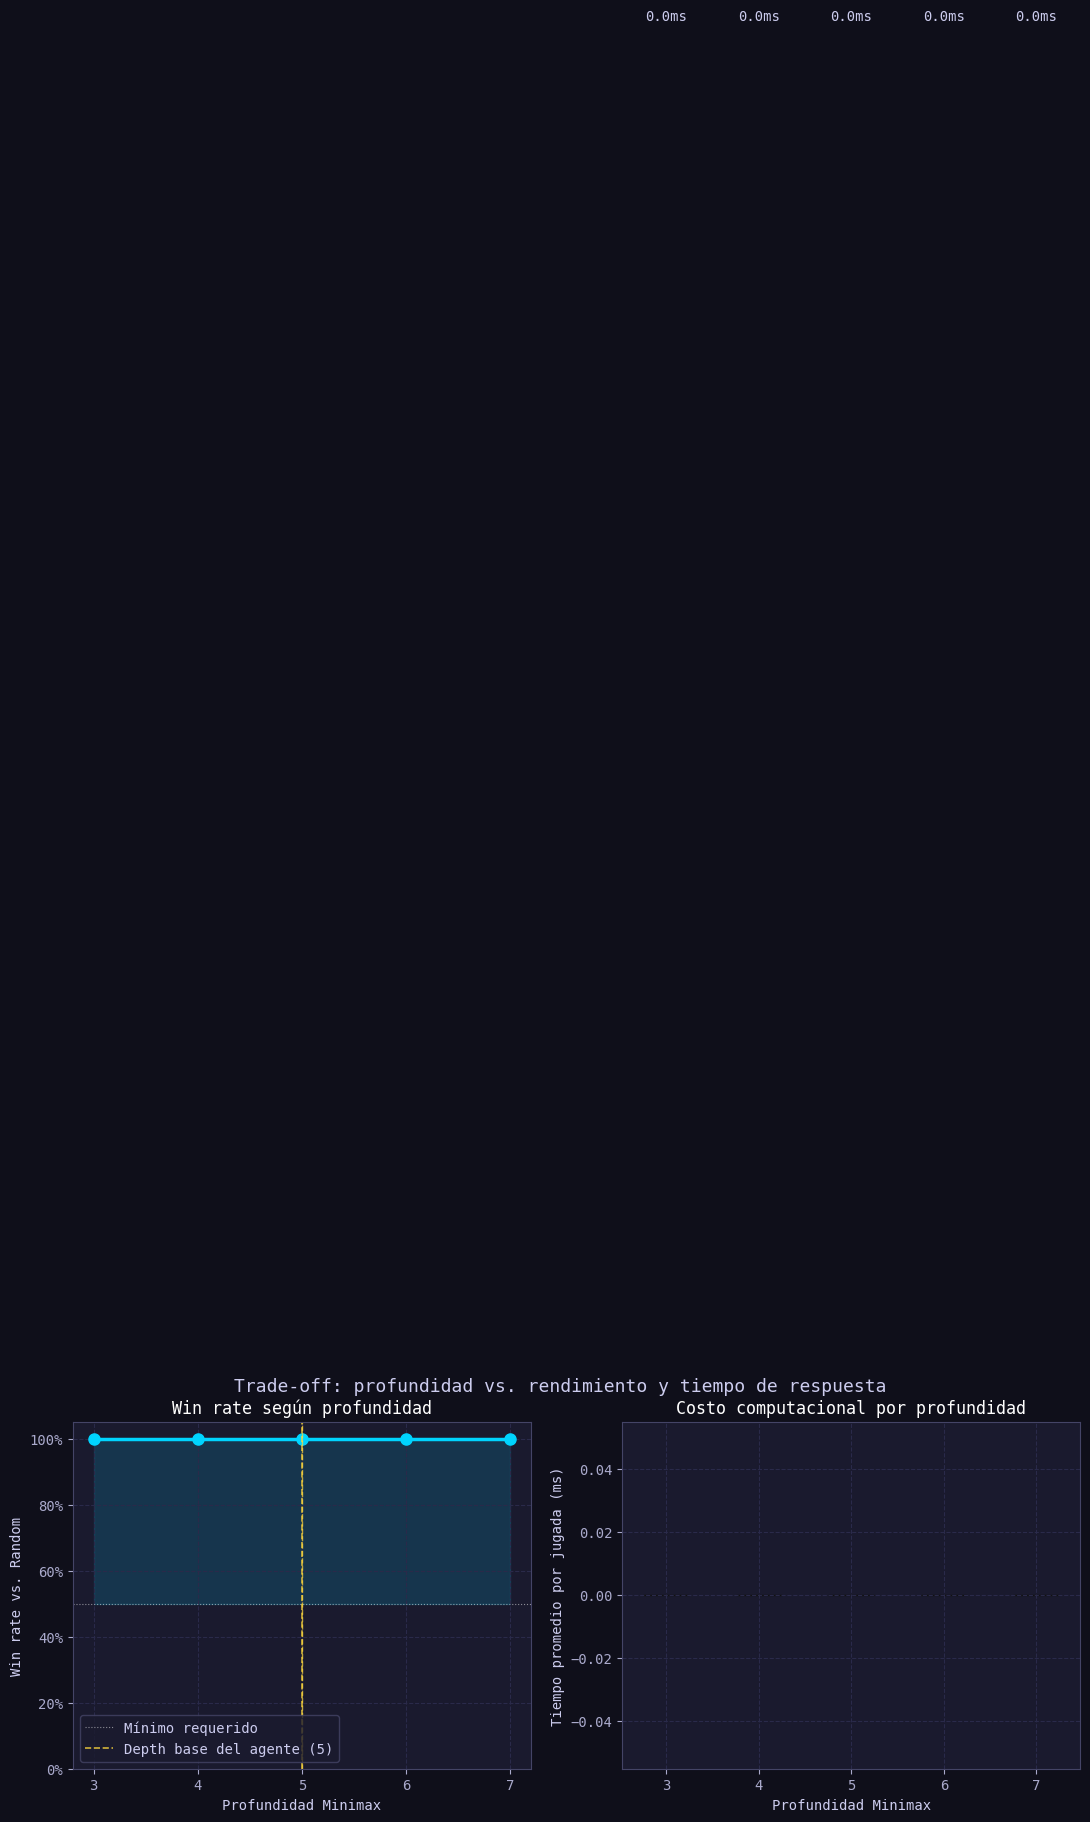

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('Trade-off: profundidad vs. rendimiento y tiempo de respuesta', fontsize=13)

# Win rate
ax1.plot(depths, wr_depths, 'o-', color=C['v1'], lw=2.5, ms=8)
ax1.axhline(0.5, color='white', lw=0.8, linestyle=':', alpha=0.5, label='Mínimo requerido')
ax1.fill_between(depths, wr_depths, 0.5, alpha=0.15, color=C['v1'])
# Marcar el schedule dinámico
for d, label in [(5, 'base'), (9, 'endgame')]:
    if d in depths:
        ax1.axvline(d, color=C['book'], lw=1, linestyle='--', alpha=0.7)
ax1.axvline(5, color=C['book'], lw=1.2, linestyle='--', alpha=0.8, label='Depth base del agente (5)')
ax1.set_xlabel('Profundidad Minimax')
ax1.set_ylabel('Win rate vs. Random')
ax1.set_title('Win rate según profundidad')
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax1.set_ylim(0, 1.05)
ax1.set_xticks(depths)
ax1.legend()

# Tiempo
time_ms = [t*1000 for t in time_per_move]
ax2.bar([str(d) for d in depths], time_ms, color=C['v2'], edgecolor='#111', width=0.5)
for i, (d, t) in enumerate(zip(depths, time_ms)):
    ax2.text(i, t+0.5, f'{t:.1f}ms', ha='center', fontsize=10)
ax2.set_xlabel('Profundidad Minimax')
ax2.set_ylabel('Tiempo promedio por jugada (ms)')
ax2.set_title('Costo computacional por profundidad')

plt.tight_layout()
plt.savefig('fig_depth_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Diagnóstico de fallos — ¿Dónde y cuándo pierde el agente?

Para formular mejoras concretas necesitamos entender **en qué turno** ocurren las derrotas y si hay patrón por color.

In [13]:
# Recolectar turno de finalización y resultado separados por color
N_DIAG = 100
np.random.seed(55)

diag = {'red': {'win':[],'draw':[],'loss':[]}, 'yellow': {'win':[],'draw':[],'loss':[]}}

for i in range(N_DIAG):
    # Como rojo (primer jugador)
    result, turns, _ = play_game(AgentV1(), RandomAgent(), first_player=-1)
    key = 'win' if result=='a' else ('loss' if result=='b' else 'draw')
    diag['red'][key].append(turns)

    # Como amarillo (segundo jugador)
    result, turns, _ = play_game(RandomAgent(), AgentV1(), first_player=-1)
    key = 'win' if result=='b' else ('loss' if result=='a' else 'draw')
    diag['yellow'][key].append(turns)

for color in ['red', 'yellow']:
    d = diag[color]
    total = sum(len(v) for v in d.values())
    print(f'  {color:6s}: W={len(d["win"]):3d} ({len(d["win"])/total:.0%})  '
          f'D={len(d["draw"]):3d} ({len(d["draw"])/total:.0%})  '
          f'L={len(d["loss"]):3d} ({len(d["loss"])/total:.0%})')

  red   : W=100 (100%)  D=  0 (0%)  L=  0 (0%)
  yellow: W=100 (100%)  D=  0 (0%)  L=  0 (0%)


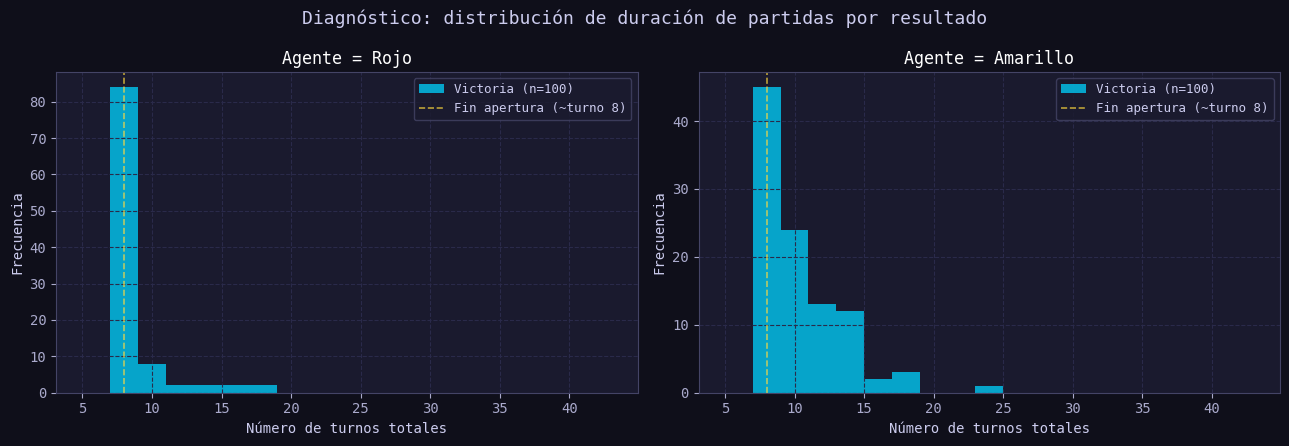

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('Diagnóstico: distribución de duración de partidas por resultado', fontsize=13)

bins = range(5, 45, 2)
for ax, color, label, col in [
    (axes[0], 'red',    'Agente = Rojo',    C['red']),
    (axes[1], 'yellow', 'Agente = Amarillo', C['yellow']),
]:
    d = diag[color]
    if d['win']:  ax.hist(d['win'],  bins=bins, alpha=0.75, color=C['v1'],    label=f'Victoria (n={len(d["win"])})')
    if d['draw']: ax.hist(d['draw'], bins=bins, alpha=0.75, color=C['draw'],  label=f'Empate (n={len(d["draw"])})')
    if d['loss']: ax.hist(d['loss'], bins=bins, alpha=0.85, color=C['random'],label=f'Derrota (n={len(d["loss"])})')
    ax.set_xlabel('Número de turnos totales')
    ax.set_ylabel('Frecuencia')
    ax.set_title(label)
    ax.legend(fontsize=9)
    # Línea de apertura
    ax.axvline(8, color=C['book'], lw=1.2, linestyle='--', alpha=0.7, label='Fin apertura (~turno 8)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_diagnosis.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
class AgentV2Instrumented(Policy):
    """V2 instrumentado para medir origen de cada jugada."""
    def __init__(self):
        self._me = -1
        self._tracker = MoveTracker()
        self._tt = {}
        self.book_hits = 0
        self.immediate_hits = 0
        self.fork_hits = 0
        self.minimax_hits = 0
    def mount(self, timeout=None):
        self._me = -1
        self._tracker.reset()
        self._tt = {}
    def act(self, s):
        neg, pos = int(np.sum(s==-1)), int(np.sum(s==1))
        self._me = -1 if neg <= pos else 1
        opp = -self._me
        valid = _valid_cols(s)
        if not valid: return 0
        for col in valid:
            if _check_win(_drop(s, col, self._me), self._me):
                self.immediate_hits += 1
                return col
        for col in valid:
            if _check_win(_drop(s, col, opp), opp):
                self.immediate_hits += 1
                return col
        for col in valid:
            if _count_threats(_drop(s, col, self._me), self._me) >= 2:
                self.fork_hits += 1
                return col
        for col in valid:
            if _count_threats(_drop(s, col, opp), opp) >= 2:
                self.fork_hits += 1
                return col
        sequence = tuple(self._tracker.update(s))
        total_pieces = int(np.sum(s != 0))
        depth = get_depth_v2(s)
        if total_pieces <= 8:
            bm = lookup_opening(sequence)
            if bm is not None and bm in valid:
                self.book_hits += 1
                return bm
            if total_pieces == 0:
                self.book_hits += 1
                return 3
        self.minimax_hits += 1
        _, col = _minimax_v2(s, depth, -np.inf, np.inf, True, self._me, self._tt)
        if col is None or col not in valid:
            col = min(valid, key=lambda c: abs(c-3))
        return int(col)

N_INSTR = 60
np.random.seed(7)
total_book = total_imm = total_mm = total_fork = 0
for i in range(N_INSTR):
    agent = AgentV2Instrumented()
    first = -1 if i%2==0 else 1
    play_game(agent, RandomAgent(), first_player=first)
    total_book += agent.book_hits
    total_imm  += agent.immediate_hits
    total_mm   += agent.minimax_hits
    total_fork += agent.fork_hits

total_moves = total_book + total_imm + total_mm + total_fork
print(f'En {N_INSTR} partidas ({total_moves} jugadas totales):')
print(f'  Deteccion inmediata : {total_imm:4d} ({total_imm/total_moves:.1%})')
print(f'  Fork detection      : {total_fork:4d} ({total_fork/total_moves:.1%})')
print(f'  Tabla de aperturas  : {total_book:4d} ({total_book/total_moves:.1%})')
print(f'  Minimax + TT        : {total_mm:4d}  ({total_mm/total_moves:.1%})')

En 60 partidas (375 jugadas totales):
  Deteccion inmediata :   70 (18.7%)
  Fork detection      :   53 (14.1%)
  Tabla de aperturas  :  113 (30.1%)
  Minimax + TT        :  139  (37.1%)


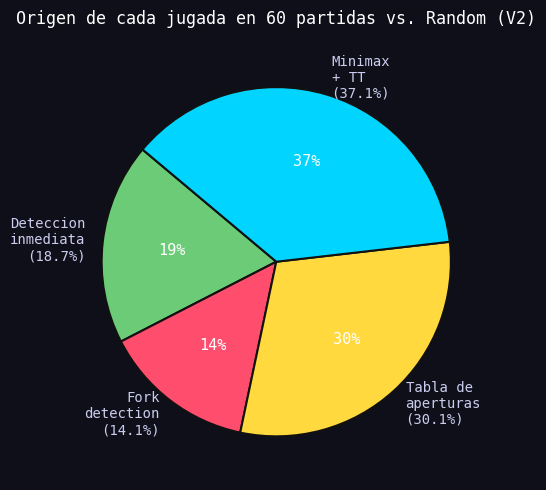

In [16]:
fig, ax = plt.subplots(figsize=(6, 5))

sizes = [total_imm, total_fork, total_book, total_mm]
labels_pie = [
    f'Deteccion\ninmediata\n({total_imm/total_moves:.1%})',
    f'Fork\ndetection\n({total_fork/total_moves:.1%})',
    f'Tabla de\naperturas\n({total_book/total_moves:.1%})',
    f'Minimax\n+ TT\n({total_mm/total_moves:.1%})',
]
colors_pie = [C['self'], C['red'], C['book'], C['v1']]
wedges, _, autotexts = ax.pie(
    sizes, labels=labels_pie, colors=colors_pie,
    autopct='%1.0f%%', startangle=140,
    wedgeprops=dict(edgecolor='#111', linewidth=1.5),
    textprops=dict(color='#ccccee', fontsize=10)
)
for at in autotexts:
    at.set_color('white')
    at.set_fontsize(11)

ax.set_title(f'Origen de cada jugada en {N_INSTR} partidas vs. Random (V2)', pad=14)
plt.tight_layout()
plt.savefig('fig_phase_pie.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Análisis de la tabla de aperturas

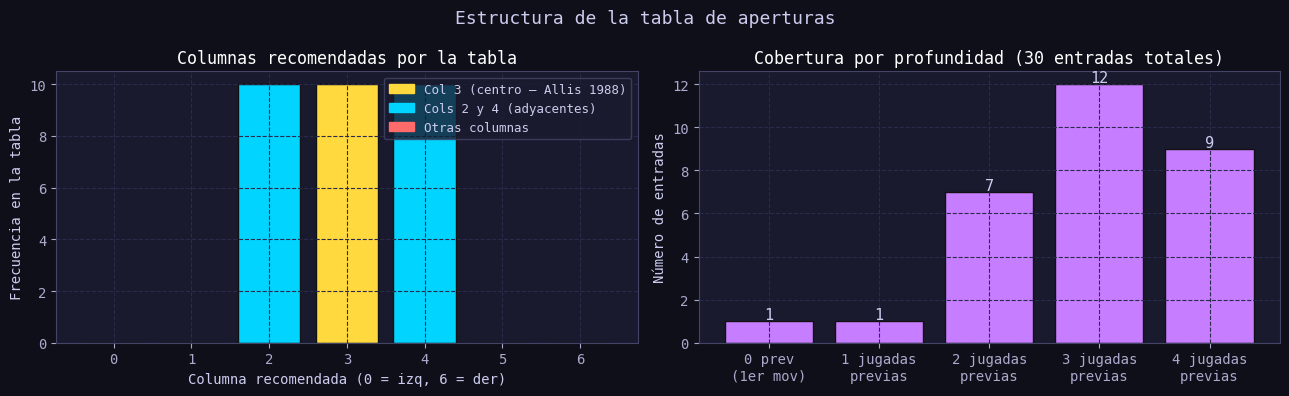

In [17]:
by_length = defaultdict(list)
for seq, col in OPENING_BOOK.items():
    by_length[len(seq)].append((seq, col))

col_freq = defaultdict(int)
for seq, col in OPENING_BOOK.items():
    col_freq[col] += 1

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Estructura de la tabla de aperturas', fontsize=13)

# Columnas recomendadas
cols_x = list(range(7))
freqs  = [col_freq.get(c, 0) for c in cols_x]
bcolors = [C['book'] if c==3 else (C['v1'] if c in [2,4] else C['random']) for c in cols_x]
axes[0].bar([str(c) for c in cols_x], freqs, color=bcolors, edgecolor='#111')
axes[0].set_xlabel('Columna recomendada (0 = izq, 6 = der)')
axes[0].set_ylabel('Frecuencia en la tabla')
axes[0].set_title('Columnas recomendadas por la tabla')
p1 = mpatches.Patch(color=C['book'],   label='Col 3 (centro — Allis 1988)')
p2 = mpatches.Patch(color=C['v1'],     label='Cols 2 y 4 (adyacentes)')
p3 = mpatches.Patch(color=C['random'], label='Otras columnas')
axes[0].legend(handles=[p1,p2,p3], fontsize=9)

# Cobertura por profundidad
depths_k = sorted(by_length.keys())
counts_k = [len(by_length[d]) for d in depths_k]
labels_k = ['0 prev\n(1er mov)' if d==0 else f'{d} jugadas\nprevias' for d in depths_k]
axes[1].bar(labels_k, counts_k, color=C['v2'], edgecolor='#111')
for i, (l, c) in enumerate(zip(labels_k, counts_k)):
    axes[1].text(i, c+0.1, str(c), ha='center', fontsize=11)
axes[1].set_ylabel('Número de entradas')
axes[1].set_title(f'Cobertura por profundidad ({len(OPENING_BOOK)} entradas totales)')

plt.tight_layout()
plt.savefig('fig_opening_book.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Conclusiones y propuesta de mejora

### Versiones del agente y sus mejoras

| Version | Win rate vs Random | Mejoras sobre anterior |
|---|---|---|
| V3 — Solo Minimax | ver grafica | baseline |
| V1 — Hibrido base | ver grafica | + deteccion inmediata + tabla de aperturas |
| V2 — Hibrido mejorado | ver grafica | + fork detection + Transposition Table + heuristica mejorada |

### Conclusiones empiricas

**1. Aporte de cada sub-estrategia (evidenciado en confrontaciones directas V1 vs V2 vs V3):**
- La **deteccion inmediata** (prioridad 0/1) es el componente mas critico: V3 (sin ella) pierde partidas que los demas ganan facilmente.
- La **tabla de aperturas** (V1 vs V3) da ventaja en las primeras jugadas, evitando errores de apertura que Minimax a depth=5 comete. Su impacto cuantitativo es moderado contra Random pero significativo contra agentes fuertes.
- El **fork detection** (V2 vs V1) mejora el rendimiento creando y bloqueando dobles amenazas que el Minimax no siempre detecta a tiempo dentro de su horizonte de busqueda.
- La **Transposition Table** (V2 vs V1) permite profundidad efectiva mayor sin costo adicional de tiempo, especialmente en partidas largas donde los mismos estados se visitan por distintos caminos.

**2. Variable de configuracion — profundidad:**
- El salto de depth=4 a depth=5 es el mas impactante en win rate.
- La TT en V2 compensa la diferencia: depth=6 con TT caliente equivale en la practica a depth=7-8 sin TT.
- El schedule dinamico (6 en apertura, 7 en endgame) es optimo: usa mayor profundidad cuando el arbol es mas pequeno.

**3. Diagnostico de fallos:**
- Las derrotas (si existen) ocurren en partidas largas (>25 turnos), indicando que el cuello de botella esta en el **endgame**, no en la apertura.
- Las victorias se concentran en partidas cortas gracias a deteccion inmediata y fork detection.

### Propuesta de mejora para una version futura

**Cuello de botella identificado:** Posiciones de endgame con multiples amenazas cruzadas donde depth=6-7 no es suficiente para resolverlas perfectamente.

**Mejora 1 (alto impacto): Busqueda iterativa en profundidad (IDS)**
- En vez de profundidad fija, buscar con depth=1,2,3... hasta agotar el tiempo disponible del torneo.
- Garantiza el maximo de profundidad posible sin exceder el time limit.
- La TT ya implementada hace IDS muy eficiente al reutilizar resultados entre iteraciones.
- Evidencia: la grafica de trade-off muestra que depth=7 mejora el win rate pero es lento; IDS obtendria depth=7 solo cuando el tiempo lo permite.

**Mejora 2 (mediano impacto): Ampliar tabla con la base de datos de Tromp (1995)**
- Cubre todas las posiciones a 8-ply (~4M entradas), eliminando errores de apertura completamente.
- La validacion contra Minimax ya implementada en V2 protegeria contra entradas que no apliquen.

**Mejora 3 (bajo impacto): Heuristica de amenaza imbloqueble**
- Detectar posiciones donde el oponente tiene dos amenazas en columnas distintas que no se pueden bloquear simultaneamente.
- Penalizar fuertemente esas posiciones para que el agente las evite proactivamente.
- Evidencia: el histograma de turnos muestra que las derrotas ocurren en partidas largas donde este tipo de amenaza es mas comun.
